# Machine Learning Assignment

**Name : Rahul          ---------------- Roll no. : UE238076              
Name : Rahul Burdak  ---------Roll no. : UE238077                
Name : Rahul Choudhary  -----Roll no. : UE238078**


Importing Libraries

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

Loading Data

In [89]:
df=pd.read_csv("/content/student_habits_performance.csv")

Dataset contains several features related to students lifestyle and study habits such as study hours, sleep, attendance, screen time, and mental health. Using these features, we are predicting the exam_score of students.

In [90]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


Basic Data Inspection

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1010 non-null   object 
 1   age                            1010 non-null   int64  
 2   gender                         1010 non-null   object 
 3   study_hours_per_day            1010 non-null   float64
 4   social_media_hours             1010 non-null   float64
 5   netflix_hours                  1010 non-null   float64
 6   part_time_job                  1010 non-null   object 
 7   attendance_percentage          1010 non-null   float64
 8   sleep_hours                    1010 non-null   float64
 9   diet_quality                   1009 non-null   object 
 10  exercise_frequency             1010 non-null   int64  
 11  parental_education_level       919 non-null    object 
 12  internet_quality               999 non-null    o

In [92]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1010.000000,1010.000000,1010.000000,1010.000000,1010.000000,1010.000000,1010.000000,1010.000000,1010.000000
mean,21.463366,3.557525,2.509406,1.820495,84.183861,6.476337,3.031683,5.463366,73.245050
std,14.273804,1.463479,1.167252,1.069806,9.367102,1.221879,2.018003,2.844699,52.036212
min,17.000000,0.000000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,19.000000,2.600000,1.700000,1.000000,78.100000,5.600000,1.000000,3.000000,58.600000
50%,20.000000,3.500000,2.500000,1.800000,84.500000,6.500000,3.000000,5.000000,70.700000
75%,23.000000,4.500000,3.300000,2.500000,90.900000,7.300000,5.000000,8.000000,81.575000
max,240.000000,8.300000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,1000.000000


In [93]:
df.describe(include=object)

,student_id,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
count,1010,1010,1010,1009,919,999,1010
unique,1000,3,2,3,3,3,2
top,S1999,Female,No,Fair,High School,Good,No
freq,11,491,795,436,392,444,692


In [94]:
df.duplicated().sum()

np.int64(9)

In [95]:
df.drop_duplicates(inplace=True)

In [96]:
df.duplicated().sum()

np.int64(0)

In [97]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,1


There are certain missing values in some features that should be handled separately

In [98]:
df.dropna(subset=['diet_quality'], inplace=True)

In [99]:
for column in ['parental_education_level', 'internet_quality']:
    if df[column].isnull().any():
        mode_value = df[column].mode()[0]
        df[column] = df[column].fillna(mode_value)

print('Missing values after handling:')
print(df.isnull().sum())

Missing values after handling:
student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64


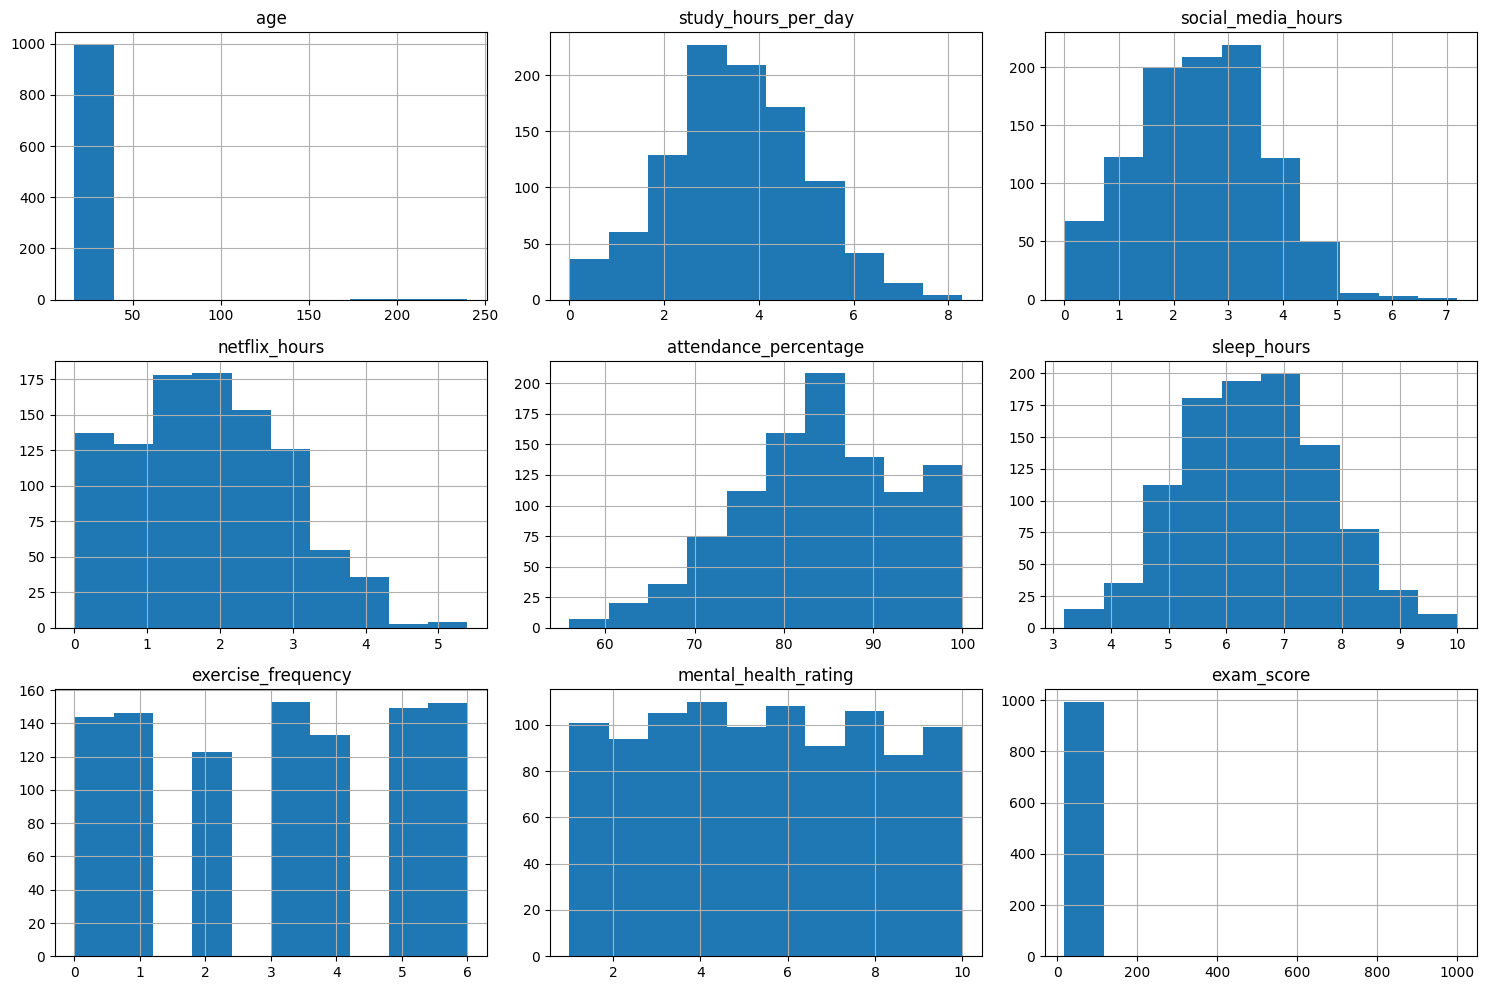

In [100]:
df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

The histograms of age and exam score are unsual due to presence of certain outliers

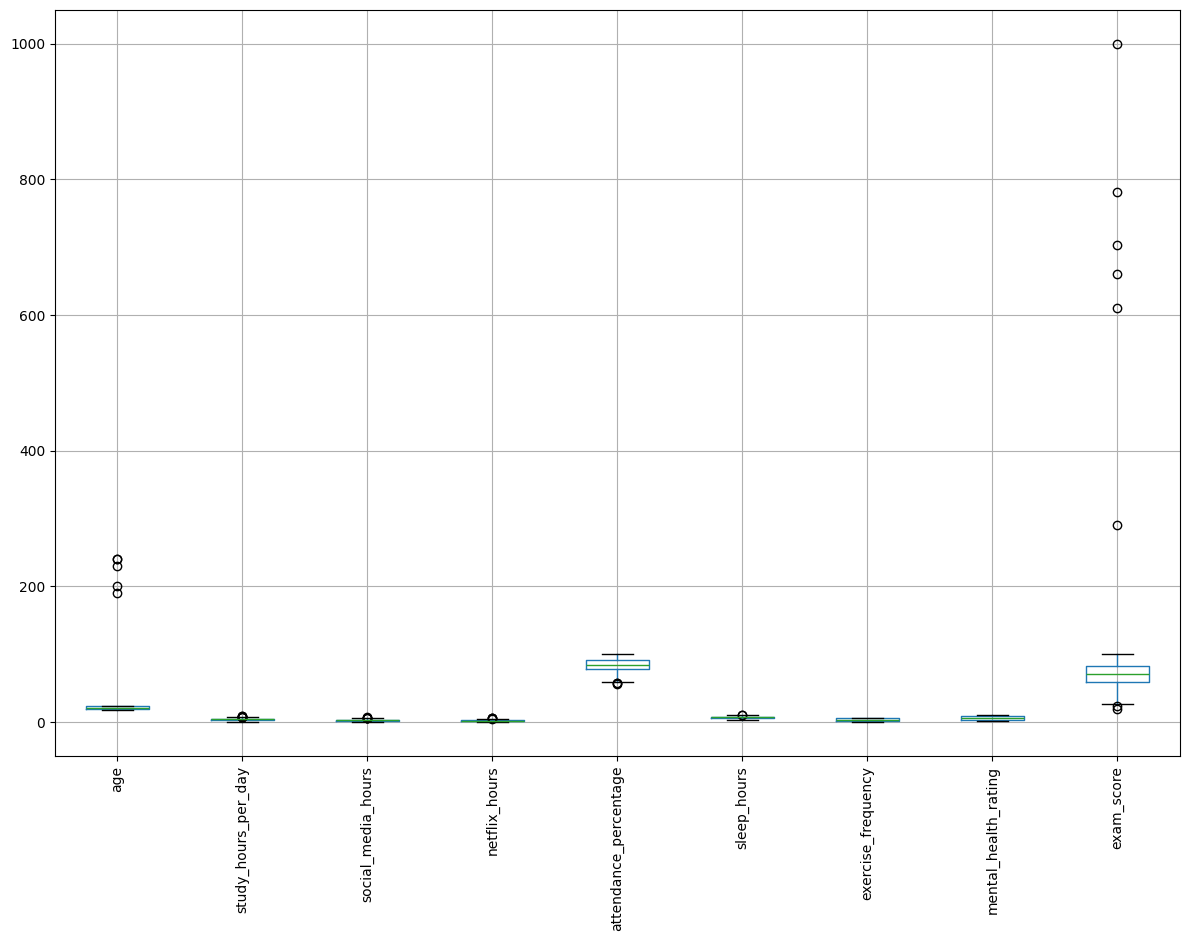

In [101]:
df.boxplot(figsize=(12, 8))
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

There are outliers in the age and exam_score features

In [102]:
print('Rows with age > 100:', df[df['age'] > 100].shape[0])
print('Rows with exam_score > 100:', df[df['exam_score'] > 100].shape[0])

Rows with age > 100: 5
Rows with exam_score > 100: 6


Removing records with unusual enteries

In [103]:
df = df[df['age'] <= 100]
df = df[df['exam_score'] <= 100]

Detecting Outliers

In [104]:
numerical_cols=df.select_dtypes(include=['number']).columns

print('Outliers detected using IQR method:')
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Column '{col}': {len(outliers)} outliers")

Outliers detected using IQR method:
Column 'age': 0 outliers
Column 'study_hours_per_day': 7 outliers
Column 'social_media_hours': 5 outliers
Column 'netflix_hours': 4 outliers
Column 'attendance_percentage': 3 outliers
Column 'sleep_hours': 2 outliers
Column 'exercise_frequency': 0 outliers
Column 'mental_health_rating': 0 outliers
Column 'exam_score': 2 outliers


Adding new features

In [105]:
df['total_screen_time']      = df['social_media_hours'] + df['netflix_hours']
df['study_to_screen_ratio']  = df['study_hours_per_day'] / (df['total_screen_time'] + 1e-6)

In [106]:
df

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,total_screen_time,study_to_screen_ratio
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2,2.3,0.000000
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0,5.1,1.352941
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3,4.4,0.318182
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8,4.9,0.204082
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4,4.9,1.020408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004,S1994,20,Female,1.6,1.3,2.9,No,75.3,5.6,Good,0,High School,Average,5,No,41.7,4.2,0.380952
1005,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1,2.1,1.238095
1006,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9,3.4,0.852941
1007,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4,3.9,0.769231


Removing student_id

In [107]:
df.drop('student_id',axis=1,inplace=True)

In [108]:
cols = df.select_dtypes(include=['object']).columns

for col in cols:
    print(f"Column: {col}")
    print(df[col].unique())

Column: gender
['Female' 'Male' 'Other']
Column: part_time_job
['No' 'Yes']
Column: diet_quality
['Fair' 'Good' 'Poor']
Column: parental_education_level
['Master' 'High School' 'Bachelor']
Column: internet_quality
['Average' 'Poor' 'Good']
Column: extracurricular_participation
['Yes' 'No']


Data Encoding

In [109]:
df = pd.get_dummies(
    df,
    columns=['part_time_job', 'extracurricular_participation'],
    drop_first=True
)

In [110]:
df['diet_quality'] = df['diet_quality'].map({
    'Poor': 0,
    'Fair': 1,
    'Good': 2
})

df['gender'] = df['gender'].map({
    'Other': 0,
    'Female': 1,
    'Male': 2
})

df['parental_education_level'] = df['parental_education_level'].map({
    'High School': 0,
    'Bachelor': 1,
    'Master': 2
})

df['internet_quality'] = df['internet_quality'].map({
    'Poor': 0,
    'Average': 1,
    'Good': 2
})

In [111]:
df

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,exam_score,total_screen_time,study_to_screen_ratio,part_time_job_Yes,extracurricular_participation_Yes
0,23,1,0.0,1.2,1.1,85.0,8.0,1,6,2,1,8,56.2,2.3,0.000000,False,True
1,20,1,6.9,2.8,2.3,97.3,4.6,2,6,0,1,8,100.0,5.1,1.352941,False,False
2,21,2,1.4,3.1,1.3,94.8,8.0,0,1,0,0,1,34.3,4.4,0.318182,False,False
3,23,1,1.0,3.9,1.0,71.0,9.2,0,4,2,2,1,26.8,4.9,0.204082,False,True
4,19,1,5.0,4.4,0.5,90.9,4.9,1,3,2,2,1,66.4,4.9,1.020408,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004,20,1,1.6,1.3,2.9,75.3,5.6,2,0,0,1,5,41.7,4.2,0.380952,False,False
1005,21,1,2.6,0.5,1.6,77.0,7.5,1,2,0,2,6,76.1,2.1,1.238095,False,True
1006,17,1,2.9,1.0,2.4,86.0,6.8,0,1,0,1,6,65.9,3.4,0.852941,True,True
1007,20,2,3.0,2.6,1.3,61.9,6.5,2,5,1,2,9,64.4,3.9,0.769231,False,True


Scaling the data

In [112]:
exclude_cols = [
    'exam_score',
    'gender',
    'diet_quality',
    'parental_education_level',
    'internet_quality',
    'mental_health_rating',
    'part_time_job_Yes',
    'extracurricular_participation_Yes'
]

scale_cols = [col for col in df.columns if col not in exclude_cols]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df[scale_cols] = scaler.fit_transform(df[scale_cols])

In [113]:
df

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,exam_score,total_screen_time,study_to_screen_ratio,part_time_job_Yes,extracurricular_participation_Yes
0,1.091562,1,-2.434027,-1.119733,-0.667695,0.090903,1.252923,1,1.462989,2,1,8,56.2,-1.269494,-0.875646,False,True
1,-0.210152,1,2.298449,0.249666,0.449177,1.397389,-1.529824,2,1.462989,0,1,8,100.0,0.485264,0.269024,False,False
2,0.223753,2,-1.473815,0.506428,-0.481550,1.131843,1.252923,0,-1.006117,0,0,1,34.3,0.046575,-0.606445,False,False
3,1.091562,1,-1.748161,1.191128,-0.760768,-1.396154,2.235069,0,0.475347,2,2,1,26.8,0.359924,-0.702981,False,True
4,-0.644056,1,0.995303,1.619065,-1.226131,0.717591,-1.284287,1,-0.018475,2,2,1,66.4,0.359924,-0.012319,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004,-0.210152,1,-1.336641,-1.034145,1.007612,-0.939415,-0.711369,2,-1.499938,0,1,5,41.7,-0.078765,-0.553338,False,False
1005,0.223753,1,-0.650775,-1.718845,-0.202332,-0.758844,0.843695,1,-0.512296,0,2,6,76.1,-1.394834,0.171857,False,True
1006,-1.511865,1,-0.445015,-1.290908,0.542249,0.197121,0.270777,0,-1.006117,0,1,6,65.9,-0.580125,-0.154007,True,True
1007,-0.210152,2,-0.376429,0.078491,-0.481550,-2.362741,0.025241,2,0.969168,1,2,9,64.4,-0.266775,-0.224831,False,True


Checking Correlation between diffrenet features

In [114]:
df.corr()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,exam_score,total_screen_time,study_to_screen_ratio,part_time_job_Yes,extracurricular_participation_Yes
age,1.000000,0.013516,0.003282,-0.001341,-0.002830,-0.027964,0.039812,0.011793,-0.000416,0.016044,0.007554,-0.040897,-0.008155,-0.002888,0.024386,-0.002862,-0.008557
gender,0.013516,1.000000,-0.030647,-0.011214,-0.013824,-0.021190,-0.046647,0.034790,0.064270,0.018735,-0.061568,-0.003789,-0.020359,-0.017519,0.015949,0.022524,-0.007130
study_hours_per_day,0.003282,-0.030647,1.000000,0.015871,-0.027135,0.030113,-0.036860,0.025985,-0.022091,-0.010269,0.018978,-0.002648,0.824123,-0.006650,0.352954,-0.031016,-0.004074
social_media_hours,-0.001341,-0.011214,0.015871,1.000000,0.010589,0.040176,0.010109,0.006106,-0.040772,-0.016474,0.034085,0.007278,-0.172163,0.739363,-0.367174,0.020123,-0.016924
netflix_hours,-0.002830,-0.013824,-0.027135,0.010589,1.000000,0.000515,-0.000146,-0.007944,-0.008106,-0.010090,0.045670,0.008055,-0.168977,0.681098,-0.331555,0.011037,-0.013466
attendance_percentage,-0.027964,-0.021190,0.030113,0.040176,0.000515,1.000000,0.012855,-0.056743,-0.012365,-0.050332,-0.047174,-0.013055,0.093595,0.029765,-0.021259,-0.039196,-0.014922
sleep_hours,0.039812,-0.046647,-0.036860,0.010109,-0.000146,0.012855,1.000000,-0.038126,0.017058,0.022035,-0.004153,-0.000648,0.118155,0.007304,0.026046,0.002496,0.023793
diet_quality,0.011793,0.034790,0.025985,0.006106,-0.007944,-0.056743,-0.038126,1.000000,0.005408,-0.023271,0.040177,0.020923,0.005993,-0.000878,0.010711,0.027377,-0.028877
exercise_frequency,-0.000416,0.064270,-0.022091,-0.040772,-0.008106,-0.012365,0.017058,0.005408,1.000000,-0.035234,-0.039647,0.001697,0.166621,-0.035313,0.026854,-0.023034,-0.005092
parental_education_level,0.016044,0.018735,-0.010269,-0.016474,-0.010090,-0.050332,0.022035,-0.023271,-0.035234,1.000000,0.046991,-0.043889,-0.026772,-0.018857,-0.004373,-0.032247,-0.003835


Exploratory Data Analysis(EDA)

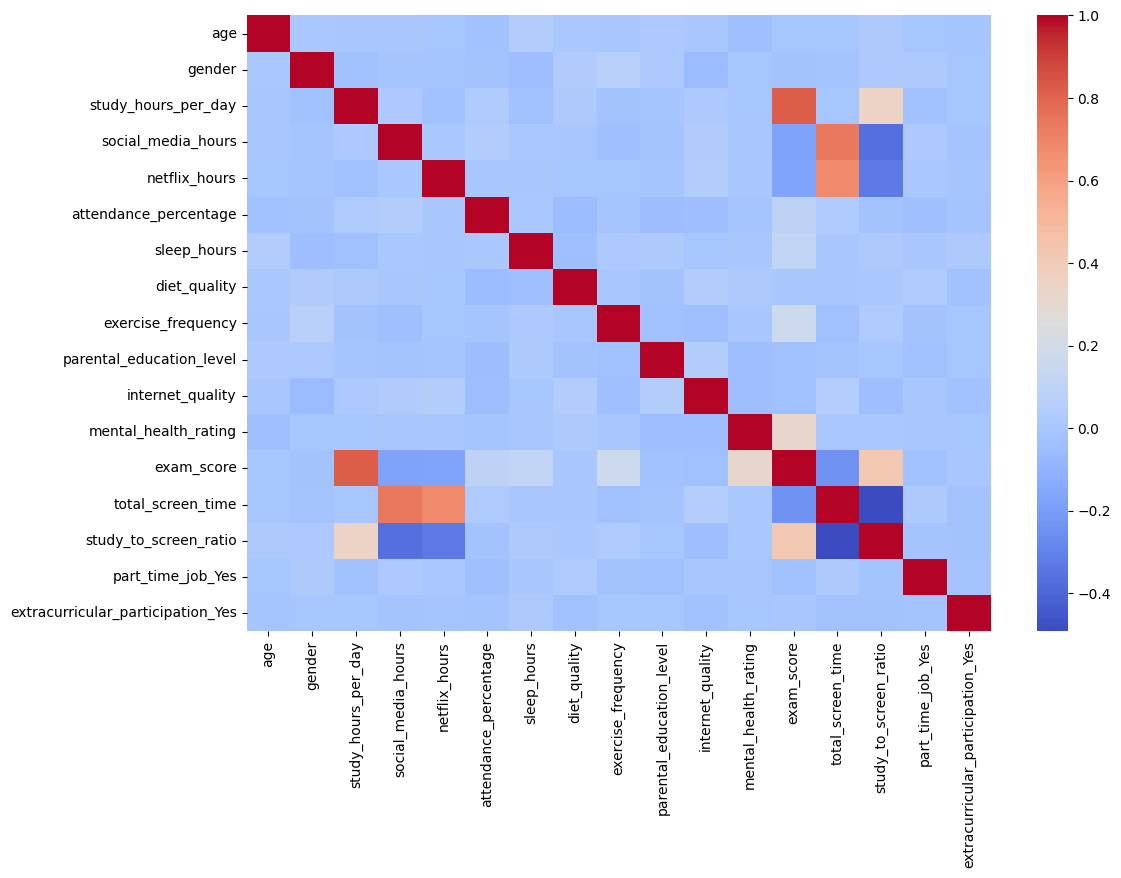

In [115]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.show()

In [116]:
corr = df.corr(numeric_only=True)
corr['exam_score'].sort_values(ascending=False)

,exam_score
exam_score,1.000000
study_hours_per_day,0.824123
study_to_screen_ratio,0.421995
mental_health_rating,0.322665
exercise_frequency,0.166621
sleep_hours,0.118155
attendance_percentage,0.093595
diet_quality,0.005993
extracurricular_participation_Yes,0.001893
age,-0.008155


The correlation analysis shows that study_hours_per_day has the strongest positive relationship with exam_score, indicating that students who study more tend to score higher. The study_to_screen_ratio and mental_health_rating also show moderate positive correlation, suggesting balanced screen usage and better mental health help improve performance

In [117]:
df.drop(['age', 'diet_quality'], axis=1, inplace=True)

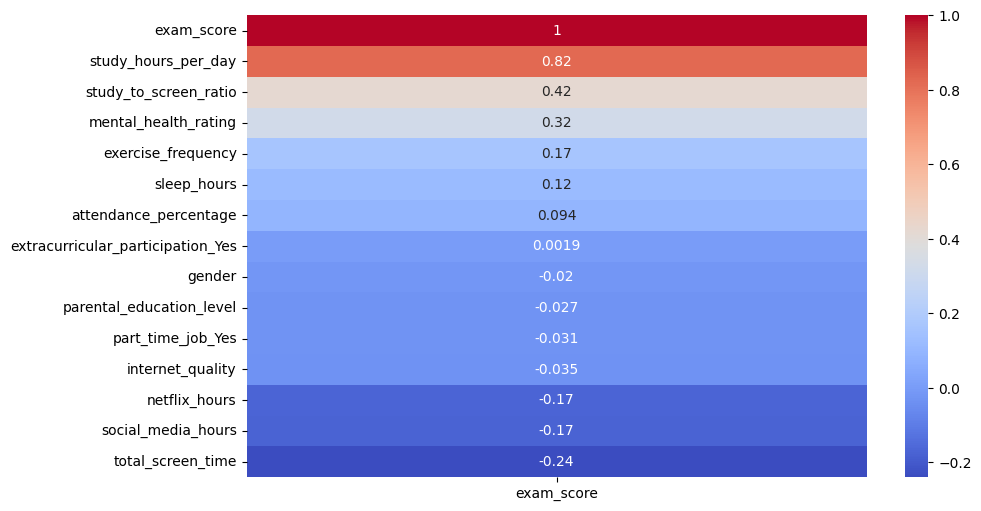

In [118]:
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr[['exam_score']].sort_values(by='exam_score', ascending=False),
            annot=True,
            cmap='coolwarm')
plt.show()

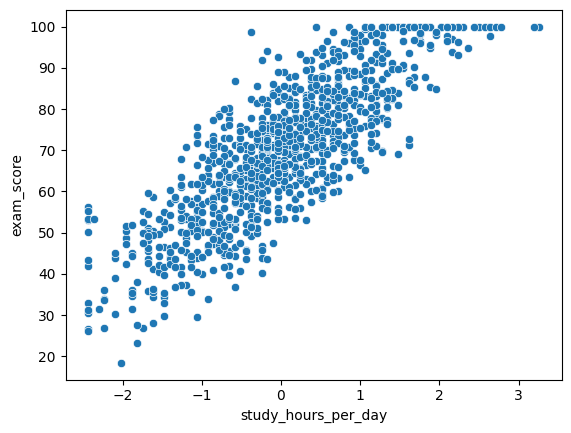

In [119]:
sns.scatterplot(x='study_hours_per_day', y='exam_score', data=df)
plt.show()

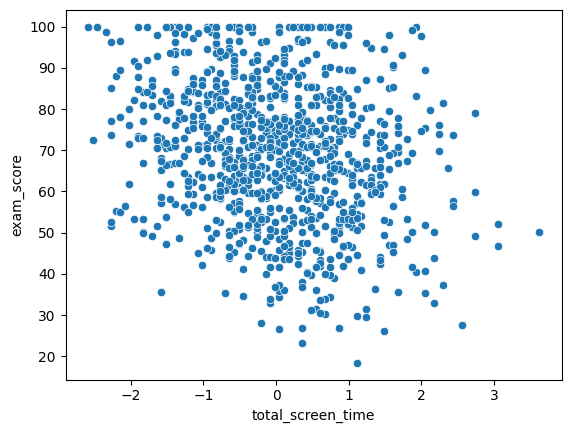

In [120]:
sns.scatterplot(x='total_screen_time', y='exam_score', data=df)
plt.show()

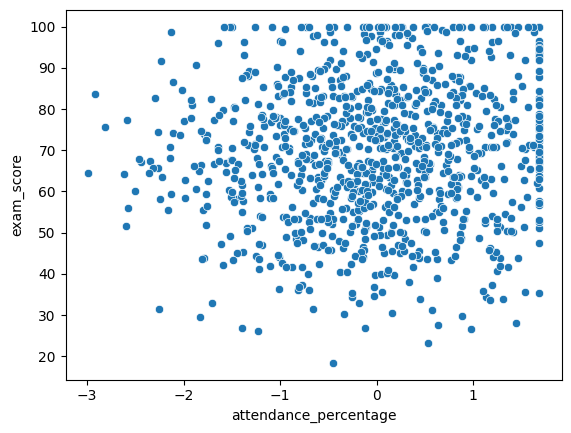

In [121]:
sns.scatterplot(x='attendance_percentage', y='exam_score', data=df)
plt.show()

Splitting the data for training

In [122]:
from sklearn.model_selection import train_test_split
X = df.drop('exam_score', axis=1)
y = df['exam_score']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42
)

print(X_train.shape, X_test.shape)

(791, 14) (198, 14)


Training with different models

In [128]:

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0),
    "LightGBM": LGBMRegressor(random_state=42)
}

train_scores = []
val_scores = []
names = []


for name, model in models.items():

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    val_r2 = r2_score(y_test, y_test_pred)

    train_scores.append(train_r2)
    val_scores.append(val_r2)
    names.append(name)

    print(f"\n{name}")
    print("Train R2:", train_r2)
    print("Val R2  :", val_r2)


Linear
Train R2: 0.9007302080202275
Val R2  : 0.8962054582933335

Ridge
Train R2: 0.9007283401404278
Val R2  : 0.8959298697269816

Lasso
Train R2: 0.8816380845685374
Val R2  : 0.8693178074511165

RandomForest
Train R2: 0.9809927102865372
Val R2  : 0.8716340847919966

XGBoost
Train R2: 0.9999260506095832
Val R2  : 0.8537590519306022
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000132 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 802
[LightGBM] [Info] Number of data points in the train set: 791, number of used features: 14
[LightGBM] [Info] Start training from score 69.920480
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

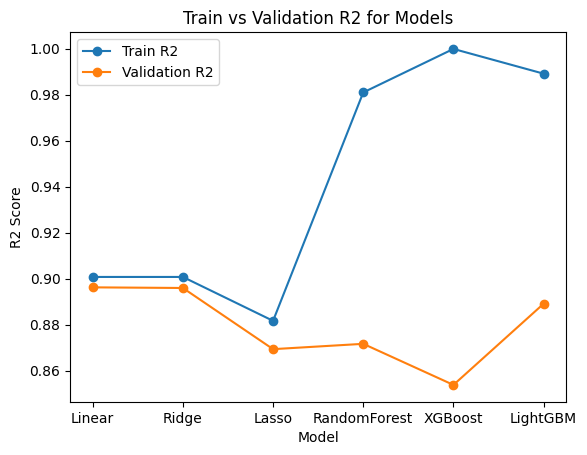

In [129]:

plt.figure()
plt.plot(names, train_scores, marker='o', label="Train R2")
plt.plot(names, val_scores, marker='o', label="Validation R2")

plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Train vs Validation R2 for Models")

plt.legend()

plt.show()

From the above graph the validation r2_score for the random forest ,xgboost,and lighGBM is very less than the training r2_score that shows the overfitting if the model . So the Best model is linear regression giving a r2_score of 0.8962 , so applying GridSearchCV on it to improve its score

In [125]:
param_grid = {
    "fit_intercept": [True, False],
    "positive": [True, False]
}
lr = LinearRegression()
grid = GridSearchCV(lr,param_grid,cv=5,scoring="r2")
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'fit_intercept': True, 'positive': False}
Best score: 0.8967223144666681


Final Linear Regression gives a score of 0.8967 after performing hyper parameter tuning using GridSearchCV